In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),  # convert 1 channel -> 3
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# train_dataset = torch.utils.data.Subset(train_dataset, range(50000))
# test_dataset = torch.utils.data.Subset(test_dataset, range(9000))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)



100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


In [ ]:
vgg = models.vgg16(pretrained=True)  # imagenet
vgg.classifier[6] = nn.Linear(4096, 10)
for param in vgg.features.parameters():
    param.requires_grad = False

vgg = vgg.to(device)
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
# for param in resnet.parameters():
#     param.requires_grad = False
# resnet.fc.requires_grad = True
resnet = resnet.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 188MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [ ]:
def train_model(model, train_loader, test_loader, epochs=3, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []
    epoch_accuracies = []
    all_preds_final = []
    all_labels_final = []


    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        acc = 100 * correct / total
        epoch_accuracies.append(acc)

        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} — Accuracy: {acc:.2f}%")

        # Save final predictions and labels for confusion matrix
        all_preds_final = all_preds
        all_labels_final = all_labels

    return epoch_losses, epoch_accuracies, all_preds_final, all_labels_final


In [ ]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(losses, accuracies, model_name="Model"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(f"{model_name} - Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1,2,2)
    plt.plot(range(1, len(accuracies)+1), accuracies, marker='o', color='green')
    plt.title(f"{model_name} - Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(preds, labels, model_name="Model"):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()


Training VGG16...
Epoch 10/10 — Loss: 0.0886 — Accuracy: 98.79%


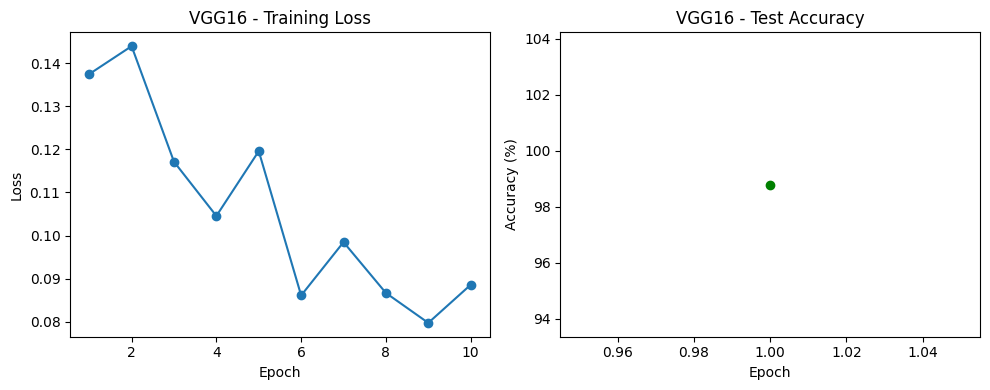

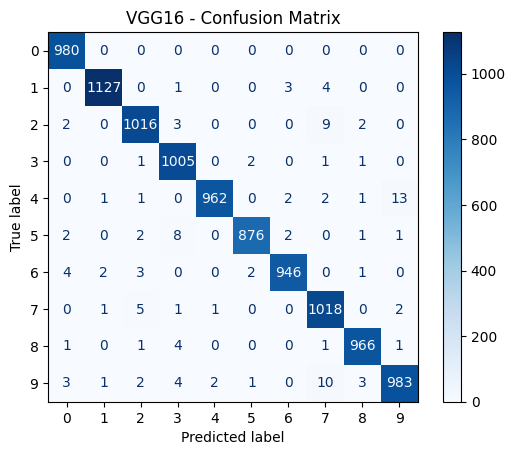

Training ResNet18...
Epoch 10/10 — Loss: 0.0043 — Accuracy: 99.45%


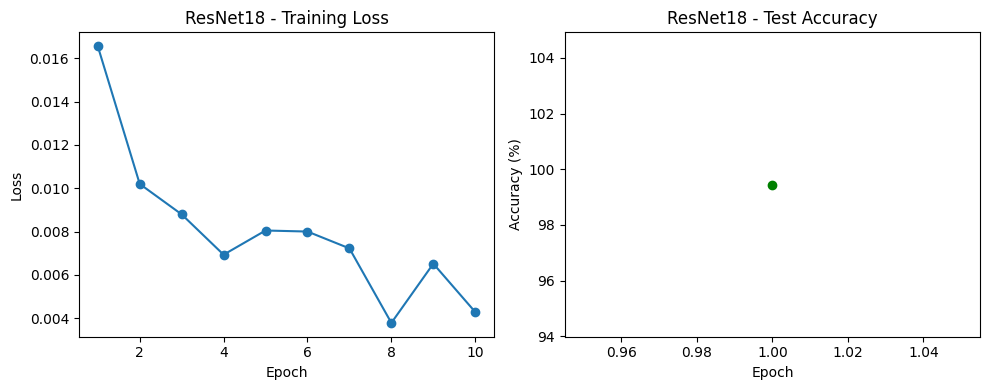

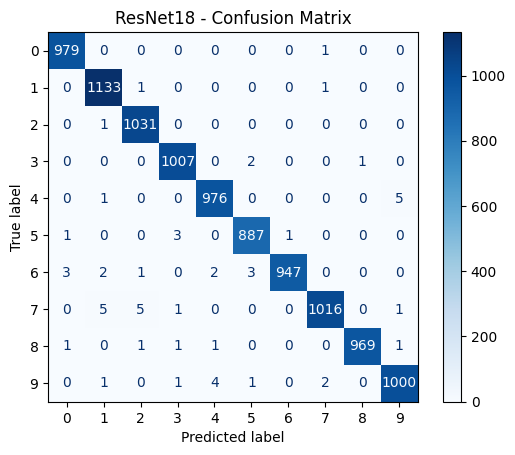

In [ ]:
print("Training VGG16...")
vgg_losses, vgg_acc, vgg_preds, vgg_labels = train_model(vgg, train_loader, test_loader, epochs=10)
plot_loss_accuracy(vgg_losses, vgg_acc, "VGG16")
plot_confusion_matrix(vgg_preds, vgg_labels, "VGG16")

print("Training ResNet18...")
resnet_losses, resnet_acc, resnet_preds, resnet_labels = train_model(resnet, train_loader, test_loader, epochs=10)
plot_loss_accuracy(resnet_losses, resnet_acc, "ResNet18")
plot_confusion_matrix(resnet_preds, resnet_labels, "ResNet18")


In [ ]:
torch.save(vgg.state_dict(), 'vgg_mnist.pth')
torch.save(resnet.state_dict(), 'resnet_mnist.pth')

torch.save(vgg, 'vgg_mnist_full.pth')
torch.save(resnet, 'resnet_mnist_full.pth')

from google.colab import files

files.download('vgg_mnist.pth')
files.download('resnet_mnist.pth')

files.download('vgg_mnist_full.pth')
files.download('resnet_mnist_full.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>